<a href="https://colab.research.google.com/github/ArsipKodeId/GenAI_GLI_2023/blob/main/AD_Classifications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Informations
Dataset: https://www.kaggle.com/datasets/marcopinamonti/alzheimer-mri-4-classes-dataset?utm_source

References Paper: https://journals.sagepub.com/doi/10.1177/1971400921990766

Architecture:
* https://docs.pytorch.org/vision/main/models/deeplabv3.html
* https://docs.pytorch.org/vision/main/models.html

## Kaggle Setup

In [2]:
!pip install kaggle

import json
import os

with open('/content/kaggle.json', 'r') as f:
    kaggle_credentials = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']

!kaggle datasets download -d marcopinamonti/alzheimer-mri-4-classes-dataset

Dataset URL: https://www.kaggle.com/datasets/marcopinamonti/alzheimer-mri-4-classes-dataset
License(s): unknown
  0% 0.00/34.1M [00:00<?, ?B/s]
100% 34.1M/34.1M [00:00<00:00, 1.42GB/s]


In [3]:
!unzip /content/alzheimer-mri-4-classes-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (46).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (47).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (48).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (49).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (5).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (50).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (51).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (52).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (53).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (54).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (55).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (56).jpg  
  inflating: Alzheimer_MRI_4_classes_dataset/NonDemented/13 (57).jpg  
  inflating: Alzheimer_MRI_

In [7]:
!mv /content/Alzheimer_MRI_4_classes_dataset/ /content/drive/MyDrive/Datasets/AD_Kaggle_2D/

## Base Config

In [1]:
import glob

In [2]:
base_path = "/content/drive/MyDrive/Datasets/AD_Kaggle_2D/Alzheimer_MRI_4_classes_dataset"

In [3]:
base_folders = glob.glob(f"{base_path}/***")

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def apply_clahe_to_image(image_path):
    """Applies CLAHE enhancement to a single image."""
    # Read the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # print(img.shape)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Create a CLAHE object (arguments are optional)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    # Apply CLAHE to the grayscale image
    clahe_img = clahe.apply(img)

    return img, clahe_img

## Image Preprocessing

Processing sample image: /content/drive/MyDrive/Datasets/AD_Kaggle_2D/Alzheimer_MRI_4_classes_dataset/NonDemented/21 (69).jpg


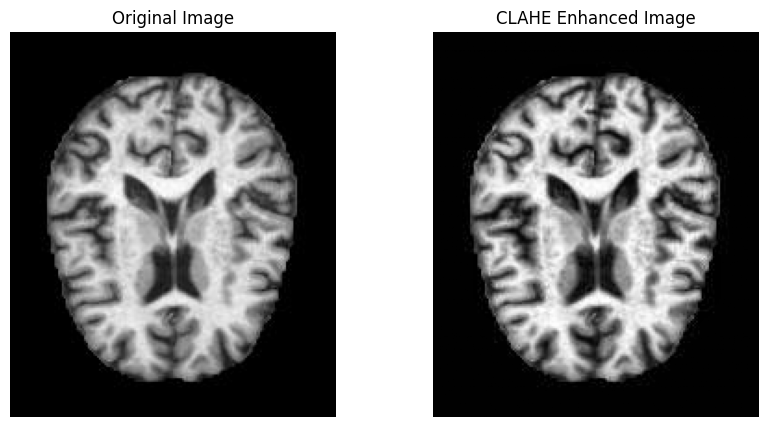

In [4]:
# Get a sample image path
# Assuming the dataset structure is base_path/Class/image.jpg
# Let's pick one from NonDemented for demonstration
sample_class_path = os.path.join(base_path, "NonDemented")
if os.path.exists(sample_class_path):
    sample_images = glob.glob(os.path.join(sample_class_path, "*.jpg"))
    if sample_images:
        sample_image_path = sample_images[0] # Take the first image as an example
        print(f"Processing sample image: {sample_image_path}")

        original_img, enhanced_img = apply_clahe_to_image(sample_image_path)

        if original_img is not None and enhanced_img is not None:
            plt.figure(figsize=(10, 5))

            plt.subplot(1, 2, 1)
            plt.imshow(original_img, cmap='gray')
            plt.title('Original Image')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(enhanced_img, cmap='gray')
            plt.title('CLAHE Enhanced Image')
            plt.axis('off')

            plt.show()
        else:
            print("Image processing failed.")
    else:
        print(f"No .jpg images found in {sample_class_path}")
else:
    print(f"Class path not found: {sample_class_path}")


In [5]:
len(glob.glob(f"{base_path}/***/***"))

6400

In [15]:
# Check the size is same
for file in base_folders:
  files = glob.glob(f"{file}/***")
  for item in files:
    img = cv2.imread(item, cv2.IMREAD_GRAYSCALE)
    if img.shape[0] != 208 or img.shape[1] != 176:
      print(item)

## Preparations Dataset

In [5]:
base_folders

['/content/drive/MyDrive/Datasets/AD_Kaggle_2D/Alzheimer_MRI_4_classes_dataset/NonDemented',
 '/content/drive/MyDrive/Datasets/AD_Kaggle_2D/Alzheimer_MRI_4_classes_dataset/VeryMildDemented',
 '/content/drive/MyDrive/Datasets/AD_Kaggle_2D/Alzheimer_MRI_4_classes_dataset/MildDemented',
 '/content/drive/MyDrive/Datasets/AD_Kaggle_2D/Alzheimer_MRI_4_classes_dataset/ModerateDemented']

In [6]:
mild_demented = glob.glob(f"{base_folders[0]}/*") ## [1,0,0,0]
moderate_demented = glob.glob(f"{base_folders[1]}/*") ## [0,1,0,0]
non_demented = glob.glob(f"{base_folders[2]}/*") #[0,0,1,0]
very_mild_demented = glob.glob(f"{base_folders[3]}/*") #[0,0,0,1]

len(mild_demented), len(moderate_demented), len(non_demented), len(very_mild_demented)

(3200, 2240, 896, 64)

In [7]:
labels_mild_demented = []
labels_moderate_demented = []
labels_non_demented = []
labels_very_mild_demented = []


for img_path in mild_demented:
    labels_mild_demented.append((img_path, [1, 0, 0, 0]))

for img_path in moderate_demented:
    labels_moderate_demented.append((img_path, [0, 1, 0, 0]))

for img_path in non_demented:
    labels_non_demented.append((img_path, [0, 0, 1, 0]))

for img_path in very_mild_demented:
    labels_very_mild_demented.append((img_path, [0, 0, 0, 1]))

len(labels_mild_demented), len(labels_moderate_demented), len(labels_non_demented), len(labels_very_mild_demented)

(3200, 2240, 896, 64)

In [8]:
def load_clahe_filter(data):
  Xdata = np.array([])
  # Check the size is same
  for file in data:
    # Apply CLAHE enhancement
    original_img, enhanced_img = apply_clahe_to_image(file) # Use the CLAHE function defined earlier

    if enhanced_img is not None:
        # Reshape the enhanced image to (1, height, width) for concatenation
        enhanced_img_reshaped = enhanced_img.reshape(1, enhanced_img.shape[0], enhanced_img.shape[1])

        if Xdata.size == 0: # Check if Xdata is empty
            Xdata = enhanced_img_reshaped
        else:
            Xdata = np.concatenate((Xdata, enhanced_img_reshaped), axis=0)

  return Xdata

def load_labels(data):
  # Initialize a list to collect the labels
  Ydata_list = []
  for file in data:
    # Append each one-hot encoded label (which is already a list/array of 4 elements)
    Ydata_list.append(file[1])
  # Convert the list of lists into a NumPy array, which will naturally create a (N, 4) shape
  return np.array(Ydata_list)


In [ ]:
# load image on preparations
import numpy as np

Xmild_demented = load_clahe_filter(mild_demented)
Xmoderate_demented = load_clahe_filter(moderate_demented)
Xnon_demented = load_clahe_filter(non_demented)
Xvery_mild_demented = load_clahe_filter(very_mild_demented)
XFull = np.concatenate((Xmild_demented, Xmoderate_demented, Xnon_demented, Xvery_mild_demented), axis=0)

print(f"Shape of Xmild_demented: {Xmild_demented.shape}")
print(f"Shape of Xmoderate_demented: {Xmoderate_demented.shape}")
print(f"Shape of Xnon_demented: {Xnon_demented.shape}")
print(f"Shape of Xvery_mild_demented: {Xvery_mild_demented.shape}")
print(f"Shape of Full: {XFull.shape}")

In [ ]:
Ymild_demented = load_labels(labels_mild_demented)
Ymoderate_demented = load_labels(labels_moderate_demented)
Ynon_demented = load_labels(labels_non_demented)
Yvery_mild_demented = load_labels(labels_very_mild_demented)
YFull = np.concatenate((Ymild_demented, Ymoderate_demented, Ynon_demented, Yvery_mild_demented), axis=0)

print(f"Shape of Ymild_demented: {Ymild_demented.shape}")
print(f"Shape of Ymoderate_demented: {Ymoderate_demented.shape}")
print(f"Shape of Ynon_demented: {Ynon_demented.shape}")
print(f"Shape of Yvery_mild_demented: {Yvery_mild_demented.shape}")
print(f"Shape of YFull: {YFull.shape}")


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Convert one-hot encoded YFull to a 1D array of class indices for stratification
stratify_labels = np.argmax(YFull, axis=1)

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(XFull, YFull, test_size=0.2, random_state=42, stratify=stratify_labels)

print(f"X_train size: {len(X_train)}")
print(f"X_test size: {len(X_test)}")
print(f"Y_train size: {len(Y_train)}")
print(f"Y_test size: {len(Y_test)}")

## Data Loader

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np

# Define a custom Dataset class
class AlzheimerMRIDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            # Convert numpy array to PIL Image for torchvision transforms
            image = image.astype(np.float32) # Ensure float32 for transforms like ToTensor
            image = self.transform(image)

        # Convert one-hot encoded label to a class index (0-3) for CrossEntropyLoss
        label = torch.tensor(np.argmax(label), dtype=torch.long) # Use torch.long for class labels
        return image, label

# Define the augmentation transforms
train_transforms = transforms.Compose([
    transforms.ToPILImage(), # Convert numpy array to PIL Image for transforms
    transforms.RandomRotation(degrees=15), # Rotate by a random angle between -15 and +15 degrees
    transforms.RandomAffine(
        degrees=0, # No additional rotation here
        translate=(0.1, 0.1), # Shift horizontally and vertically by up to 10% of image width/height
        scale=(0.9, 1.1), # Zoom in/out by up to 10%
        shear=0 # No shear
    ),
    transforms.RandomHorizontalFlip(p=0.5), # Flip horizontally with 50% probability
    transforms.RandomVerticalFlip(p=0.5),   # Flip vertically with 50% probability
    transforms.ToTensor(), # Convert PIL Image or numpy.ndarray to tensor (scales to [0,1])
    transforms.Normalize(mean=[0.5], std=[0.5]) # Normalize grayscale images to [-1, 1]
])

# Create the training dataset and dataloader
train_dataset = AlzheimerMRIDataset(X_train, Y_train, transform=train_transforms)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Optionally, create transforms and dataloader for the test set (without heavy augmentation)
test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_dataset = AlzheimerMRIDataset(X_test, Y_test, transform=test_transforms)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of testing batches: {len(test_dataloader)}")

# Verify a sample batch
for images, labels in train_dataloader:
    print("Sample training batch image shape:", images.shape)
    print("Sample training batch label shape:", labels.shape)
    print("Sample training batch label values:", labels)
    break


Number of training batches: 160
Number of testing batches: 40
Sample training batch image shape: torch.Size([32, 1, 208, 176])
Sample training batch label shape: torch.Size([32])
Sample training batch label values: tensor([0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 2, 0, 1, 1, 1, 1, 2, 2, 2,
        1, 0, 2, 1, 2, 1, 2, 0])


## Architecture

In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class AlzheimerClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super(AlzheimerClassifier, self).__init__()
        # Load pre-trained MobileNetV3Large
        self.mobilenet_v3 = models.mobilenet_v3_large(pretrained=True)

        # Modify the first convolutional layer to accept 1 input channel (grayscale image)
        original_first_conv = self.mobilenet_v3.features[0][0]
        self.mobilenet_v3.features[0][0] = nn.Conv2d(
            1,
            original_first_conv.out_channels,
            kernel_size=original_first_conv.kernel_size,
            stride=original_first_conv.stride,
            padding=original_first_conv.padding,
            bias=original_first_conv.bias
        )

        # Replace the classifier head
        num_ftrs = self.mobilenet_v3.classifier[-1].in_features
        self.mobilenet_v3.classifier[-1] = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        logits = self.mobilenet_v3(x)
        # For training with CrossEntropyLoss, return raw logits
        return logits

# Instantiate the model
model = AlzheimerClassifier(num_classes=4)

# Define device to use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("MobileNetV3 model with modified classifier loaded successfully.")
print(f"Model will run on: {device}")

# Optional: Print model summary to verify changes
# print(model)


MobileNetV3 model with modified classifier loaded successfully.
Model will run on: cpu


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [71]:
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd # Import pandas

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of epochs
num_epochs = 1

# List to store results for CSV export
results_data = []

print("Starting training...")

# Training Loop
for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Iterate over the training data
    for inputs, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} Training"):
        # Move inputs and labels to the correct device (GPU if available, else CPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataloader)
    epoch_train_accuracy = 100 * correct_train / total_train

    # Validation Loop
    model.eval() # Set model to evaluation mode
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad(): # Disable gradient calculation for evaluation
        for inputs, labels in tqdm(test_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} Testing"):
            # Move inputs and labels to the correct device (GPU if available, else CPU)
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    epoch_test_loss = test_loss / len(test_dataloader)
    epoch_test_accuracy = 100 * correct_test / total_test

    # Calculate Precision, Recall, F1-score
    precision, recall, f1_score, _ = precision_recall_fscore_support(all_labels, all_predictions, average='weighted', zero_division=0)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}%, Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_accuracy:.2f}%, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1_score:.4f}")

    # Store results for this epoch
    results_data.append({
        'epoch': epoch + 1,
        'train_loss': epoch_train_loss,
        'train_accuracy': epoch_train_accuracy,
        'test_loss': epoch_test_loss,
        'test_accuracy': epoch_test_accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score
    })

print("Training finished.")

# Save results to CSV
results_df = pd.DataFrame(results_data)
results_df.to_csv('/content/training_metrics.csv', index=False)
print("Training metrics saved to training_metrics.csv")


Starting training...


Epoch 1/1 Testing: 100%|██████████| 40/40 [00:16<00:00,  2.42it/s]

Epoch 1/1, Train Loss: 0.9288, Train Acc: 55.70%, Test Loss: 1.1938, Test Acc: 50.00%, Precision: 0.2500, Recall: 0.5000, F1-score: 0.3333
Training finished.
Training metrics saved to training_metrics.csv
